# Protocol-Style End-to-End Simulation


This notebook rewrites `examples/protocol_style_simulation.py` as a first practical `cqed_sim` workflow. We model a qubit-storage device prepared in `|g,0>`, apply a calibrated `x90` pulse, compile the schedule, simulate the dynamics, and then sample a qubit measurement.

The physical goal is simple but realistic: show how the public model, pulse-builder, compiler, solver, and measurement APIs fit together in one top-to-bottom workflow. Because the frame is matched to the bare mode frequencies, the pulse area controls the qubit rotation and the expected outcome is a final excited-state probability near `0.5`.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    QubitMeasurementSpec,
    RotationGate,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    build_rotation_pulse,
    fock_state,
    measure_qubit,
    prepare_state,
    qubit_state,
    simulate_sequence,
    storage_photon_number,
    transmon_level_populations,
)
from tutorials.tutorial_support import GHz, MHz, ns


## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-2.5),
    kerr=MHz(-0.002),
    n_cav=4,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)

initial_state = prepare_state(
    model,
    StatePreparationSpec(
        qubit=qubit_state("g"),
        storage=fock_state(0),
    ),
)

gate = RotationGate(index=0, name="x90", theta=np.pi / 2.0, phi=0.0)


## Pulse / sequence construction


In [3]:
pulses, drive_ops, pulse_meta = build_rotation_pulse(
    gate,
    {
        "duration_rotation_s": 64.0 * ns,
        "rotation_sigma_fraction": 0.18,
    },
)

compiled = SequenceCompiler(dt=1.0 * ns).compile(pulses, t_end=70.0 * ns)
print("Pulse metadata:", pulse_meta)
print("Compiled samples:", compiled.tlist.size)


Pulse metadata: {'mapping': 'Gaussian qubit drive with analytic RWA calibration theta = 2 * integral Omega(t) dt.', 'duration_s': 6.4e-08, 'drive_amp': 12271846.303085128, 'drive_phase': 0.0, 'sigma_fraction': 0.18}
Compiled samples: 71


## Simulation


In [4]:
result = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame, store_states=True),
)
measurement = measure_qubit(result.final_state, QubitMeasurementSpec(shots=2048, seed=7))

exact_probabilities = measurement.probabilities
sampled_probabilities = {
    key: value / 2048.0
    for key, value in measurement.counts.items()
}
transmon_populations = transmon_level_populations(result.final_state)
storage_n = storage_photon_number(result.final_state)

print("Exact qubit probabilities:", exact_probabilities)
print("Sampled qubit counts:", measurement.counts)
print("Final transmon populations:", transmon_populations)
print("Final storage <n>:", storage_n)


Exact qubit probabilities: {'g': 0.500297944657404, 'e': 0.49970205534259604}
Sampled qubit counts: {'g': 1037, 'e': 1011}
Final transmon populations: {0: 0.500297944657404, 1: 0.499702055342596}
Final storage <n>: 0.0


## Analysis / visualization


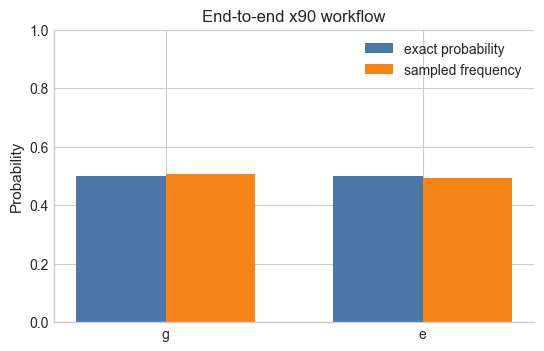

In [5]:
labels = ["g", "e"]
exact = [exact_probabilities[label] for label in labels]
sampled = [sampled_probabilities[label] for label in labels]

fig, ax = plt.subplots(figsize=(6.2, 3.8))
x = np.arange(len(labels), dtype=float)
width = 0.35
ax.bar(x - width / 2.0, exact, width=width, label="exact probability", color="#4C78A8")
ax.bar(x + width / 2.0, sampled, width=width, label="sampled frequency", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Probability")
ax.set_title("End-to-end x90 workflow")
ax.legend(loc="upper right")
plt.show()


## Interpretation


The qubit ends near an equal superposition because the Gaussian pulse builder calibrates the pulse area for a `pi/2` rotation. The cavity remains in vacuum because we never drive the storage channel.

This is the smallest realistic `cqed_sim` workflow to keep in mind when you adapt the library for your own experiments:

`model -> frame -> initial state -> pulse builder -> compiler -> simulate_sequence -> measure_qubit`


## Variations / exercises


- Change `gate.theta` to `np.pi` and confirm that the final qubit population moves close to `P_e = 1`.
- Replace the builder with a manually defined `Pulse` if you want explicit control over the envelope.
- Add cavity displacement before the qubit pulse to turn this into a cavity-conditioned protocol.
